In [55]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')
from matplotlib.lines import Line2D


In [24]:
def euler(a,b,N,alpha,phuongtrinh,filename):
    h = (b-a)/N
    x = []
    y = []

    x.append(a)
    y.append(alpha)

    for i in range(1, N+1):
        y.append(y[i-1] + h * phuongtrinh(x[i-1], y[i-1]))
        x.append(a + i*h)

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai phuong trinh vi phan\n")
        file.write("#" * 70 + "\n")
        file.write(f"#{'i':>6s}  {'x':>12s}  {'theta':>12s}  {'omega':>12s}\n")

        for i in range(N+1):
            file.write(f" {i:6d}  {x[i]:12.9f}  {y[i][0]:12.9f}  {y[i][1]:12.9f}\n")
    return x, y

In [25]:
def RK2_midpoint(a,b,N,alpha,phuongtrinh,filename):
    h = (b-a)/N
    x = []
    y = []

    x.append(a)
    y.append(alpha)

    for i in range(1, N+1):
        y.append(y[i-1] + h * phuongtrinh(x[i-1]+h/2, y[i-1]+h/2*phuongtrinh(x[i-1], y[i-1])))
        x.append(a + i*h)

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai phuong trinh vi phan\n")
        file.write("#" * 70 + "\n")
        file.write(f"#{'i':>6s}  {'x':>12s}  {'theta':>12s}  {'omega':>12s}\n")

        for i in range(N+1):
            file.write(f" {i:6d}  {x[i]:12.9f}  {y[i][0]:12.9f}  {y[i][1]:12.9f}\n")
    return x, y

In [26]:
def Euler_modified(a,b,N,alpha,phuongtrinh,filename):
    h = (b-a)/N
    x = []
    y = []

    x.append(a)
    y.append(alpha)

    for i in range(1, N+1):
        x.append(a + i*h)
        y.append(y[i-1] + h/2 * (phuongtrinh(x[i-1], y[i-1]) + phuongtrinh(x[i], y[i-1]+h*phuongtrinh(x[i-1],y[i-1]))))

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai phuong trinh vi phan\n")
        file.write("#" * 70 + "\n")
        file.write(f"#{'i':>6s}  {'x':>12s}  {'theta':>12s}  {'omega':>12s}\n")

        for i in range(N+1):
            file.write(f" {i:6d}  {x[i]:12.9f}  {y[i][0]:12.9f}  {y[i][1]:12.9f}\n")
    return x, y

In [27]:
def RK4(a, b, N, alpha, phuongtrinh, filename):
    h = (b - a) / N
    x = []
    y = []

    x.append(a)
    y.append(alpha)

    for i in range(1, N + 1):
        x.append(a + i*h)

        k1 = h * phuongtrinh(x[i-1], y[i-1])
        k2 = h * phuongtrinh(x[i-1] + h/2, y[i-1] + k1/2)
        k3 = h * phuongtrinh(x[i-1] + h/2, y[i-1] + k2/2)
        k4 = h * phuongtrinh(x[i-1] + h,   y[i-1] + k3)

        y.append(y[i-1] + (k1 + 2*k2 + 2*k3 + k4)/6)

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai phuong trinh vi phan\n")
        file.write("#" * 70 + "\n")
        file.write(f"# {'i':>6s}  {'x':>12s}  {'theta':>12s}  {'omega':>12s}\n")

        for i in range(N + 1):
            file.write(f" {i:6d}  {x[i]:12.9f}  {y[i][0]:12.9f}  {y[i][1]:12.9f}\n")
    return x, y

In [28]:
def phuongtrinh_1(t, Y):
    global g, l
    theta = Y[0]
    omega = Y[1]
    return np.array([omega, -(g/l)*np.sin(theta)])

def phuongtrinh_2(t, Y):
    global g, l
    theta = Y[0]
    omega = Y[1]
    return np.array([omega, -(g/l)*theta])


In [29]:
a = 0.0
b = 10.0
N = 1000
g = 9.81

## Cau so 1


In [30]:
theta0 = np.pi / 6      # rad
omega0 = 0.0            # rad/s
alpha = np.array([theta0, omega0])
l = 0.6

x_euler_1, y_euler_1 = euler(a, b, N, alpha, phuongtrinh_1, "cau1_euler_pt1.txt")
x_mem_1,   y_mem_1   = Euler_modified(a, b, N, alpha, phuongtrinh_1, "cau1_mem_pt1.txt")
x_rk4_1,   y_rk4_1   = RK4(a, b, N, alpha, phuongtrinh_1, "cau1_rk4_pt1.txt")

x_euler_2, y_euler_2 = euler(a, b, N, alpha, phuongtrinh_2, "cau1_euler_pt2.txt")
x_mem_2,   y_mem_2   = Euler_modified(a, b, N, alpha, phuongtrinh_2, "cau1_mem_pt2.txt")
x_rk4_2,   y_rk4_2   = RK4(a, b, N, alpha, phuongtrinh_2, "cau1_rk4_pt2.txt")

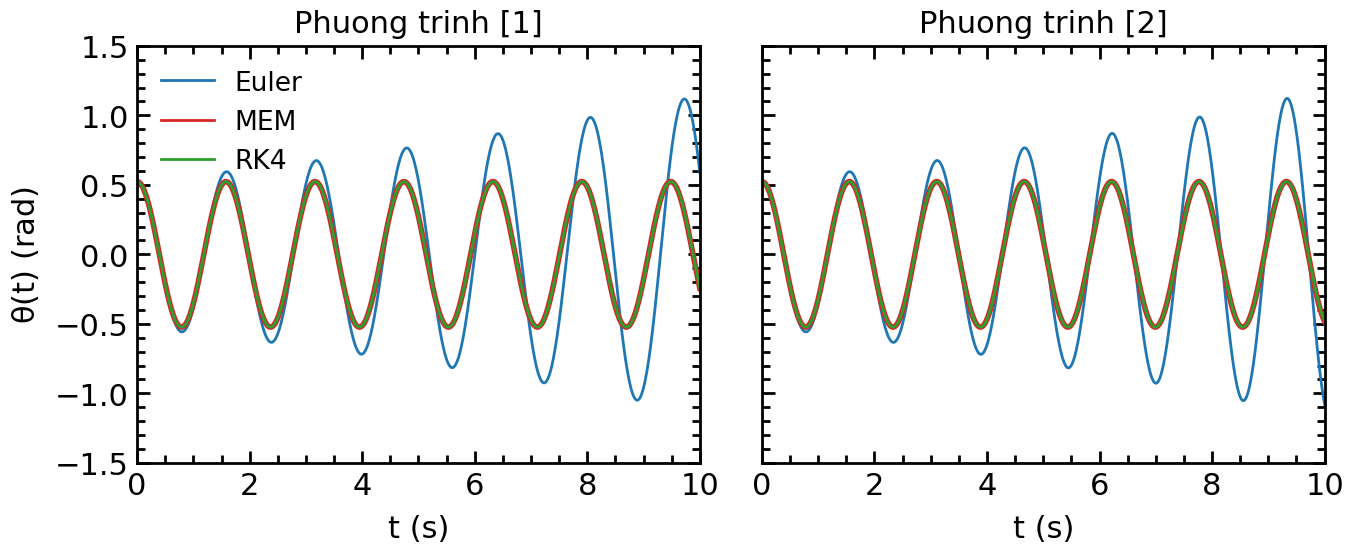

In [57]:
data_euler_1 = np.loadtxt("cau1_euler_pt1.txt", comments="#", unpack=True)
data_mem_1   = np.loadtxt("cau1_mem_pt1.txt", comments="#", unpack=True)
data_rk4_1   = np.loadtxt("cau1_rk4_pt1.txt", comments="#", unpack=True)

data_euler_2 = np.loadtxt("cau1_euler_pt2.txt", comments="#", unpack=True)
data_mem_2   = np.loadtxt("cau1_mem_pt2.txt", comments="#", unpack=True)
data_rk4_2   = np.loadtxt("cau1_rk4_pt2.txt", comments="#", unpack=True)

# PT [1]
i_euler_1, t_euler_1, theta_euler_1, omega_euler_1 = data_euler_1
i_mem_1,   t_mem_1,   theta_mem_1,   omega_mem_1   = data_mem_1
i_rk4_1,   t_rk4_1,   theta_rk4_1,   omega_rk4_1   = data_rk4_1

# PT [2]
i_euler_2, t_euler_2, theta_euler_2, omega_euler_2 = data_euler_2
i_mem_2,   t_mem_2,   theta_mem_2,   omega_mem_2   = data_mem_2
i_rk4_2,   t_rk4_2,   theta_rk4_2,   omega_rk4_2   = data_rk4_2


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].plot(t_euler_1, theta_euler_1, color='C0')
axes[0].plot(t_mem_1,   theta_mem_1,   color='C1', lw=4)
axes[0].plot(t_rk4_1,   theta_rk4_1,   color='C2')

axes[0].set_xlabel("t (s)")
axes[0].set_ylabel(r"$\theta(t)$ (rad)")
axes[0].set_title("Phuong trinh [1]")
axes[0].set_xlim(0, 10)
axes[0].set_ylim(-1.5, 1.5)

legend_handles = [
    Line2D([0], [0], color='C0', lw=2, label='Euler'),
    Line2D([0], [0], color='C1', lw=2, label='MEM'),
    Line2D([0], [0], color='C2', lw=2, label='RK4')
]
axes[0].legend(handles=legend_handles)

axes[1].plot(t_euler_2, theta_euler_2, color='C0')
axes[1].plot(t_mem_2,   theta_mem_2,   color='C1', lw=4)
axes[1].plot(t_rk4_2,   theta_rk4_2,   color='C2')

axes[1].set_xlabel("t (s)")
axes[1].set_title("Phuong trinh [2]")
axes[1].set_xlim(0, 10)
axes[1].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.savefig('Bai1.pdf')
plt.show()

## Bai 2

In [60]:
omega0 = 0.0            # rad/s
l = 0.6

theta0 = np.pi / 12      # rad
alpha = np.array([theta0, omega0])
x_rk4_1,   y_rk4_1   = RK4(a, b, N, alpha, phuongtrinh_1, "cau2_rk4_pi_12_pt1.txt")
x_rk4_2,   y_rk4_2   = RK4(a, b, N, alpha, phuongtrinh_2, "cau2_rk4_pi_12_pt2.txt")

theta0 = np.pi / 4      # rad
alpha = np.array([theta0, omega0])
x_rk4_1,   y_rk4_1   = RK4(a, b, N, alpha, phuongtrinh_1, "cau2_rk4_pi_4_pt1.txt")
x_rk4_2,   y_rk4_2   = RK4(a, b, N, alpha, phuongtrinh_2, "cau2_rk4_pi_4_pt2.txt")